# Table of contents

#4.5. Preprocessing cho LLM Fine-tuning (LoRA/QLoRA)

#5.5. LLM Input Representation

#6.3.5. LLM NLI Baseline

#11. Evaluation (phần NLI Evaluation; Retrieval Evaluation phụ thuộc module IR của TV3)

#12. Error Analysis

#13. Conclusion & Future Work

# Config

In [1]:
# !pip -q install pandas matplotlib


In [2]:
import json
import re
import unicodedata
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/TV4")
except ImportError:
    PROJECT_DIR = Path.cwd().parent

DATA_PATH = PROJECT_DIR / "data" / "processed" / "common_cleaned"

OUTPUT_PATH = PROJECT_DIR / "TV4" / "outputs"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

PROMPT_PATH = PROJECT_DIR / "TV4" / "prompts"
PROMPT_PATH.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_PATH:", DATA_PATH)

LABEL_MAP = {0: "Supported", 1: "Refuted", 2: "NEI"}

splits = {}
for name in ["train", "dev", "test"]:
    splits[name] = pd.read_csv(DATA_PATH / f"vifactcheck_{name}_common_cleaned.csv")
    print(name, splits[name].shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/TV4
DATA_PATH: /content/drive/MyDrive/TV4/data/processed/common_cleaned
train (5062, 10)
dev (723, 10)
test (1447, 10)


# 4.5. Preprocessing cho LLM Fine-tuning (TV4)

Theo bảng quy trình đồ án, preprocessing cho LLM khác hẳn với TF-IDF/BamiBERT/PhoBERT: KHÔNG tách từ,
KHÔNG loại stopword, KHÔNG xóa dấu câu, KHÔNG lowercase — vì LLM dùng tokenizer riêng (subword/BPE) và
cần giữ nguyên văn phong tự nhiên (dấu câu, số liệu, chữ hoa/thường) để tận dụng kiến thức pretraining.
Chỉ áp dụng: Unicode normalization nhẹ + sửa lỗi kỹ thuật nghiêm trọng (nếu có).

In [3]:
def check_unicode_nfc(series: pd.Series) -> int:
    """Đếm số dòng CHƯA ở dạng chuẩn Unicode NFC."""
    not_nfc = series.astype(str).apply(lambda s: unicodedata.normalize("NFC", s) != s)
    return int(not_nfc.sum())


def check_html_or_url(series: pd.Series) -> int:
    """Đếm số dòng có chuỗi giống HTML tag hoặc URL."""
    pattern = re.compile(r"(<[^>]+>|https?://\S+|www\.\S+)")
    hits = series.astype(str).apply(lambda s: bool(pattern.search(s)))
    return int(hits.sum())


def check_double_space(series: pd.Series) -> int:
    """Đếm số dòng còn khoảng trắng kép (dấu hiệu chưa chuẩn hóa whitespace)."""
    pattern = re.compile(r"\s{2,}")
    hits = series.astype(str).apply(lambda s: bool(pattern.search(s)))
    return int(hits.sum())


rows = []
for name, df in splits.items():
    for col in ["Statement", "Context", "Evidence"]:
        rows.append(
            {
                "split": name,
                "field": col,
                "n_rows": len(df),
                "not_nfc_normalized": check_unicode_nfc(df[col]),
                "contains_html_or_url": check_html_or_url(df[col]),
                "contains_double_space": check_double_space(df[col]),
                "n_missing": int(df[col].isna().sum()),
            }
        )

preprocessing_report = pd.DataFrame(rows)
preprocessing_report.to_csv(OUTPUT_PATH / "01_preprocessing_check.csv", index=False)
preprocessing_report

,split,field,n_rows,not_nfc_normalized,contains_html_or_url,contains_double_space,n_missing
0,train,Statement,5062,0,2,0,0
1,train,Context,5062,0,120,0,0
2,train,Evidence,5062,0,4,0,0
3,dev,Statement,723,0,1,0,0
4,dev,Context,723,0,15,0,0
5,dev,Evidence,723,0,1,0,0
6,test,Statement,1447,0,2,0,0
7,test,Context,1447,0,33,0,0
8,test,Evidence,1447,0,2,0,0


**Kết quả kiểm tra (train/dev/test):**

- 0 dòng lệch chuẩn Unicode NFC, 0 dòng thiếu dữ liệu (missing), 0 dòng còn khoảng trắng kép ở cả 3
  trường Statement/Context/Evidence trên cả 3 split.
- Vẫn còn một số dòng chứa chuỗi giống URL/HTML (chủ yếu ở Context — vài chục dòng mỗi split). Kiểm
  tra thủ công cho thấy đây là URL/email/hotline THẬT nằm trong nội dung bài báo gốc (ví dụ link
  website chính thức, trang bán vé, hotline liên hệ), không phải lỗi kỹ thuật.

**Kết luận:** Bản `common_cleaned` đã đủ cho LLM fine-tuning — KHÔNG cần làm sạch thêm.

## 5.5. LLM Input Representation

Thiết kế input theo dạng **Instruction + Claim + Evidence → Label**, thử nghiệm 2 định dạng:

1. **Plain text** (template dạng Alpaca/instruction-tuning phổ biến).
2. **Structured JSON** (mỗi mẫu là một object JSON với các field rõ ràng).

Với Train/Dev: đưa `Label` vào cuối chuỗi (target để model học sinh ra). Với Test: bỏ `Label` khỏi
input (model phải tự dự đoán), nhãn thật lưu riêng ở field `gold_label` để chấm điểm.

In [4]:
INSTRUCTION = (
    "Xác định mối quan hệ giữa Claim và Evidence. "
    "Trả lời đúng một trong ba nhãn: "
    "Supported (Evidence xác nhận Claim đúng), "
    "Refuted (Evidence bác bỏ Claim), "
    "hoặc NEI (không đủ thông tin để xác định)."
)


def build_prompt_plain(row: pd.Series, include_label: bool) -> str:
    """Dựng prompt dạng plain text (### Instruction / Claim / Evidence / Label)."""
    text = (
        f"### Instruction:\n{INSTRUCTION}\n\n"
        f"### Claim:\n{row['Statement']}\n\n"
        f"### Evidence:\n{row['Evidence']}\n\n"
        f"### Label:\n"
    )
    if include_label:
        text += LABEL_MAP[row["labels"]]
    return text


def build_prompt_json(row: pd.Series, include_label: bool) -> dict:
    """Dựng prompt dạng structured JSON."""
    obj = {
        "instruction": INSTRUCTION,
        "claim": row["Statement"],
        "evidence": row["Evidence"],
    }
    if include_label:
        obj["label"] = LABEL_MAP[row["labels"]]
    return obj


print(build_prompt_plain(splits["train"].iloc[0], include_label=True))

### Instruction:
Xác định mối quan hệ giữa Claim và Evidence. Trả lời đúng một trong ba nhãn: Supported (Evidence xác nhận Claim đúng), Refuted (Evidence bác bỏ Claim), hoặc NEI (không đủ thông tin để xác định).

### Claim:
Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất truyền hình và TP. Hải Phòng sau 2 năm gián đoạn do đại dịch COVID-19 đã tổ chức rất thành công sự kiện quan trọng này.

### Evidence:
Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất truyền hình và TP. Hải Phòng đã tổ chức rất thành công sự kiện quan trọng này sau 2 năm gián đoạn do đại dịch COVID-19.

### Label:
Supported


In [5]:
# Sinh file JSONL cho train/dev/test, cả 2 định dạng plain & json
for name, df in splits.items():
    include_label = name in (
        "train",
        "dev",
    )  # test: giữ nhãn thật riêng ở gold_label để chấm điểm

    plain_path = PROMPT_PATH / f"tv4_prompt_plain_{name}.jsonl"
    json_path = PROMPT_PATH / f"tv4_prompt_json_{name}.jsonl"

    with open(plain_path, "w", encoding="utf-8") as fp, open(
        json_path, "w", encoding="utf-8"
    ) as fj:
        for _, row in df.iterrows():
            rec_plain = {"text": build_prompt_plain(row, include_label)}
            if not include_label:
                rec_plain["gold_label"] = LABEL_MAP[row["labels"]]
            fp.write(json.dumps(rec_plain, ensure_ascii=False) + "\n")

            rec_json = build_prompt_json(row, include_label)
            if not include_label:
                rec_json["gold_label"] = LABEL_MAP[row["labels"]]
            fj.write(json.dumps(rec_json, ensure_ascii=False) + "\n")

    print(name, "->", plain_path, json_path)

train -> /content/drive/MyDrive/TV4/TV4/prompts/tv4_prompt_plain_train.jsonl /content/drive/MyDrive/TV4/TV4/prompts/tv4_prompt_json_train.jsonl
dev -> /content/drive/MyDrive/TV4/TV4/prompts/tv4_prompt_plain_dev.jsonl /content/drive/MyDrive/TV4/TV4/prompts/tv4_prompt_json_dev.jsonl
test -> /content/drive/MyDrive/TV4/TV4/prompts/tv4_prompt_plain_test.jsonl /content/drive/MyDrive/TV4/TV4/prompts/tv4_prompt_json_test.jsonl


Thống kê độ dài prompt (đếm theo token tách khoảng trắng, cùng cách TV1 đã dùng ở mục EDA) để chọn `max_length` khi tokenize cho model thật:

In [6]:
def word_count(s: str) -> int:
    return len(s.split())


length_rows = []
length_data = {"plain": {}, "json": {}}
for name in splits:
    for fmt in ["plain", "json"]:
        path = PROMPT_PATH / f"tv4_prompt_{fmt}_{name}.jsonl"
        lens = []
        with open(path, encoding="utf-8") as f:
            for line in f:
                obj = json.loads(line)
                text = (
                    obj.get("text")
                    if fmt == "plain"
                    else json.dumps(obj, ensure_ascii=False)
                )
                lens.append(word_count(text))
        s = pd.Series(lens)
        length_rows.append(
            {
                "split": name,
                "format": fmt,
                "mean": round(s.mean(), 2),
                "median": s.median(),
                "p95": int(s.quantile(0.95)),
                "max": int(s.max()),
                "n": len(s),
            }
        )
        length_data[fmt][name] = lens

prompt_length_stats = pd.DataFrame(length_rows)
prompt_length_stats.to_csv(OUTPUT_PATH / "02_prompt_length_stats.csv", index=False)
prompt_length_stats

,split,format,mean,median,p95,max,n
0,train,plain,124.19,120.0,181,346,5062
1,train,json,120.19,116.0,177,342,5062
2,dev,plain,123.86,119.0,177,302,723
3,dev,json,119.86,115.0,173,298,723
4,test,plain,123.12,118.0,178,315,1447
5,test,json,120.12,115.0,175,312,1447


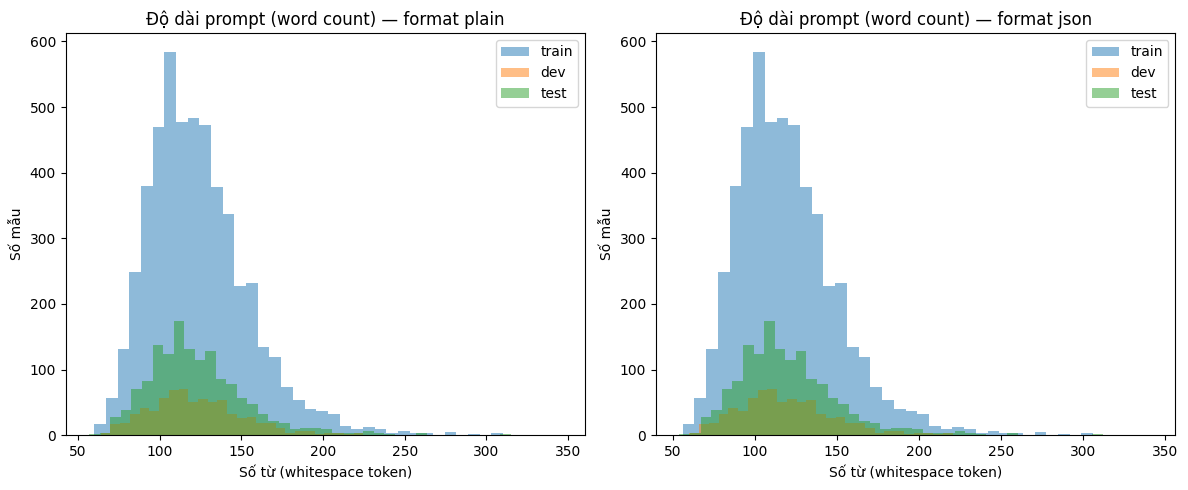

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, fmt in zip(axes, ["plain", "json"]):
    for name in splits:
        ax.hist(length_data[fmt][name], bins=40, alpha=0.5, label=name)
    ax.set_title(f"Độ dài prompt (word count) — format {fmt}")
    ax.set_xlabel("Số từ (whitespace token)")
    ax.set_ylabel("Số mẫu")
    ax.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_PATH / "03_prompt_length_histograms.png", dpi=150, bbox_inches="tight"
)
plt.show()

**Nhận xét:** p95 ≈ 178-181 từ, max ≈ 300-346 từ ở cả 2 format, khá đồng đều giữa train/dev/test
(không có lệch phân phối giữa các split). Vì subword tokenizer của LLM thường tách một từ tiếng Việt
thành 1.2-1.6 token, `max_length = 512` là lựa chọn an toàn (đủ dư so với max quan sát được), nên dùng
làm điểm khởi đầu; cần re-check lại bằng tokenizer thật của model đã chọn trước khi train chính thức.

In [8]:
# Vài ví dụ minh họa (một ví dụ mỗi nhãn), dùng cho báo cáo/slide
example_rows = []
for lbl, name_lbl in LABEL_MAP.items():
    sample = splits["train"][splits["train"]["labels"] == lbl].iloc[0]
    example_rows.append(
        {
            "label": name_lbl,
            "statement": sample["Statement"],
            "evidence": sample["Evidence"],
        }
    )
prompt_examples = pd.DataFrame(example_rows)
prompt_examples.to_csv(OUTPUT_PATH / "04_prompt_examples.csv", index=False)
prompt_examples

,label,statement,evidence
0,Supported,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ,...","Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó T..."
1,Refuted,SAWACO thông báo tạm ngưng cung cấp nước để th...,SAWACO thông báo tạm ngưng cung cấp nước để th...
2,NEI,"CLB luôn chuẩn bị rất kỹ lưỡng, chỉn chu chươn...",Là chương trình lớn nhất của CLB trong năm nên...


## 6.3.5. LLM NLI Baseline: Fine-tuning LoRA/QLoRA

Note: Phải chạy trên Colab vì máy cá nhân không có GPU

In [9]:
# Cài thư viện cho fine-tuning (CẦN GPU)
# !pip -q install -U transformers accelerate peft bitsandbytes datasets trl torchao


In [10]:
import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from trl import SFTConfig, SFTTrainer

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
USE_4BIT = False
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

quant_config = None
if USE_4BIT:
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16 if not USE_4BIT else None,
)
if USE_4BIT:
    model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


In [11]:
train_ds = load_dataset(
    "json", data_files=str(PROMPT_PATH / "tv4_prompt_plain_train.jsonl"), split="train"
)
dev_ds = load_dataset(
    "json", data_files=str(PROMPT_PATH / "tv4_prompt_plain_dev.jsonl"), split="train"
)

RESPONSE_TEMPLATE = "### Label:\n"


def split_prompt_completion(example):
    prompt, _, completion = example["text"].partition(RESPONSE_TEMPLATE)
    return {"prompt": prompt + RESPONSE_TEMPLATE, "completion": completion}


train_ds = train_ds.map(split_prompt_completion, remove_columns=train_ds.column_names)
dev_ds = dev_ds.map(split_prompt_completion, remove_columns=dev_ds.column_names)

sft_config = SFTConfig(
    output_dir="tv4_llm_lora_checkpoints",
    max_length=MAX_LENGTH,  # trl >= 0.20 đổi tên từ max_seq_length
    completion_only_loss=True,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    bf16=True,
    report_to=[],
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
)

trainer.train()
trainer.save_model("tv4_llm_lora_adapter")
tokenizer.save_pretrained("tv4_llm_lora_adapter")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5062 [00:00<?, ? examples/s]

Map:   0%|          | 0/723 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/5062 [00:00<?, ? examples/s]

...

Dropping fully masked examples from eval dataset:   0%|          | 0/723 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.180690,0.188717,0.168797,862392.000000,0.928016
2,0.115642,0.183652,0.094345,1724784.000000,0.944154


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.180690,0.188717,0.168797,862392.000000,0.928016
2,0.115642,0.183652,0.094345,1724784.000000,0.944154
3,0.039012,0.194463,0.066553,2587176.000000,0.941701


('tv4_llm_lora_adapter/tokenizer_config.json',
 'tv4_llm_lora_adapter/chat_template.jinja',
 'tv4_llm_lora_adapter/tokenizer.json')

Sau khi train xong, sinh dự đoán trên tập Test bằng generation (greedy) và parse nhãn từ text sinh ra:

In [13]:
import re as _re

VALID_LABELS = ["Supported", "Refuted", "NEI"]


def parse_label(generated_text: str) -> str:
    """Lấy nhãn hợp lệ đầu tiên xuất hiện trong text model sinh ra; None nếu không khớp nhãn nào."""
    for label in VALID_LABELS:
        if _re.search(_re.escape(label), generated_text, flags=_re.IGNORECASE):
            return label
    return None


@torch.no_grad()
def predict_label(prompt_text: str) -> str:
    inputs = tokenizer(
        prompt_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH
    ).to(model.device)
    output_ids = model.generate(
        **inputs,
        max_new_tokens=8,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )
    generated = tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True
    )
    return parse_label(generated) or "UNPARSED"


test_records = [
    json.loads(line)
    for line in open(PROMPT_PATH / "tv4_prompt_plain_test.jsonl", encoding="utf-8")
]

predictions = []
for rec in test_records:
    pred = predict_label(rec["text"])
    predictions.append({"gold_label": rec["gold_label"], "pred_label": pred})

pred_df = pd.DataFrame(predictions)
pred_df.to_csv(OUTPUT_PATH / "05_test_predictions.csv", index=False)
pred_df.head()

,gold_label,pred_label
0,Refuted,NEI
1,NEI,NEI
2,Supported,Supported
3,NEI,NEI
4,Supported,Supported


## 11. Evaluation

Gồm 2 phần theo quy trình đồ án:
- **11.1 Retrieval Evaluation** (Recall@1/3/5): đánh giá module IR (tìm evidence) =>>> ĐỢI THÀNH VIÊN 3
- **11.2 NLI Evaluation**: Accuracy, Precision, Recall, Macro-F1, Confusion Matrix cho LLM NLI Baseline
  — dùng trực tiếp `pred_df` sinh ra ở mục 6.3.5.

In [ ]:
def recall_at_k(
    gold_evidence_ids: list, retrieved_ids_per_query: list, k: int
) -> float:
    """Recall@K cho bài toán Evidence Retrieval.

    gold_evidence_ids: list các id evidence đúng, 1 phần tử / câu hỏi (query).
    retrieved_ids_per_query: list, mỗi phần tử là danh sách id đã retrieve (đã sắp theo rank) cho 1 query.
    Cần plug output thật của module IR (TV3) vào đây — hiện chưa có nên chưa tính được số liệu.
    """
    hits = 0
    for gold_id, retrieved_ids in zip(gold_evidence_ids, retrieved_ids_per_query):
        if gold_id in retrieved_ids[:k]:
            hits += 1
    return hits / len(gold_evidence_ids)


# TODO(TV3 -> TV4): gọi recall_at_k(gold_ids, retrieved_ids, k) với k in [1, 3, 5] khi có output IR.

In [14]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
import seaborn as sns

# pred_df đến từ mục 6.3.5 (dự đoán LLM trên test set)
y_true = pred_df["gold_label"]
y_pred = pred_df["pred_label"]

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(
        y_true, y_pred, average="macro", zero_division=0
    ),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
}
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(OUTPUT_PATH / "06_nli_evaluation_metrics.csv", index=False)
print(classification_report(y_true, y_pred, zero_division=0))
metrics_df

              precision    recall  f1-score   support

         NEI       0.87      0.89      0.88       471
     Refuted       0.87      0.86      0.87       468
   Supported       0.86      0.86      0.86       508

    accuracy                           0.87      1447
   macro avg       0.87      0.87      0.87      1447
weighted avg       0.87      0.87      0.87      1447



,accuracy,precision_macro,recall_macro,macro_f1
0,0.870076,0.870243,0.870202,0.870169


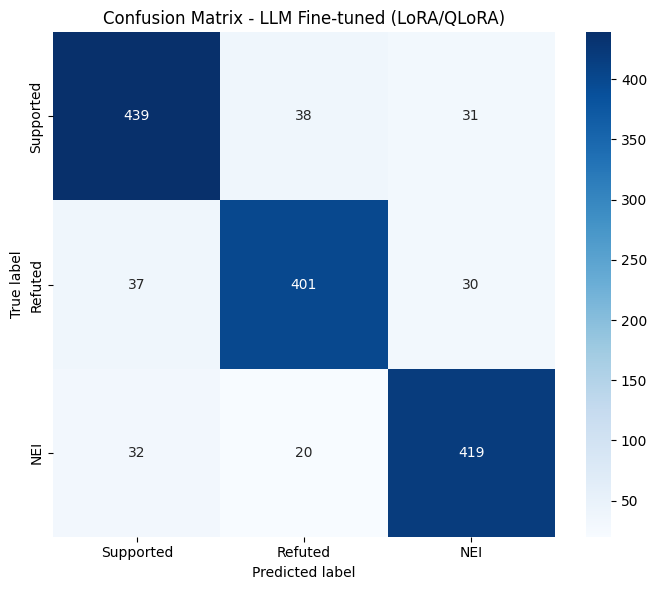

In [15]:
label_order = VALID_LABELS + (["UNPARSED"] if "UNPARSED" in y_pred.unique() else [])
cm = confusion_matrix(y_true, y_pred, labels=label_order)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order,
)
plt.title("Confusion Matrix - LLM Fine-tuned (LoRA/QLoRA)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "07_confusion_matrix_test.png", dpi=200, bbox_inches="tight")
plt.show()

**Bảng so sánh Macro-F1 giữa các model (trên tập Test; TV2/TV3 điền sau khi có kết quả):**

| Model | Macro-F1 (Test) |
|---|---:|
| TF-IDF + Logistic Regression (TV1) | 0.3811 |
| BamiBERT SOTA (TV3) | 84.84% |
| PhoBERT (TV2) | *(điền sau)* |
| BamiBERT (TV2) | *(điền sau)* |
| **LLM Fine-tuned (Qwen2.5-1.5B-Instruct, LoRA) — TV4** | **0.8702** |

TV4 vượt xa baseline TF-IDF (0.38 → 0.87), đúng như kỳ vọng vì LLM instruction-tuned tận dụng được
ngữ nghĩa/quan hệ Statement-Evidence thay vì chỉ khớp từ vựng như bag-of-words. Accuracy = 0.8701,
Precision/Recall macro ≈ 0.870, không lệch nhãn nào rõ rệt (xem `06_nli_evaluation_metrics.csv` và
confusion matrix `07_confusion_matrix_test.png`).

## 12. Error Analysis

Phân tích lỗi NLI theo các nguyên nhân điển hình được nêu trong quy trình đồ án: câu dài, phủ định,
quan hệ nhân quả, số liệu gần giống nhau. Cần `pred_df` (mục 6.3.5) đã có prediction thật để chạy được
đoạn dưới — hiện chưa có số liệu vì mục 6.3.5 chưa chạy.

In [16]:
NEGATION_WORDS = ["không", "chưa", "chẳng", "chả", "đâu có", "không hề"]
NUMBER_PATTERN = re.compile(r"\d+([.,]\d+)?\s*%?")


def error_signals(statement: str, evidence: str) -> dict:
    """Gắn cờ các tín hiệu có thể liên quan tới lỗi NLI, để nhóm case sai theo nguyên nhân."""
    text = f"{statement} {evidence}"
    has_negation = any(neg in text.lower() for neg in NEGATION_WORDS)
    is_long = len(text.split()) > 120  # ngưỡng tham khảo p95 ở mục 5.5
    numbers_statement = set(NUMBER_PATTERN.findall(statement))
    numbers_evidence = set(NUMBER_PATTERN.findall(evidence))
    has_close_numbers = (
        bool(numbers_statement)
        and bool(numbers_evidence)
        and numbers_statement != numbers_evidence
    )
    return {
        "has_negation": has_negation,
        "is_long": is_long,
        "has_close_numbers": has_close_numbers,
    }


test_df = splits["test"].reset_index(drop=True)
error_df = pred_df.copy()
error_df["statement"] = test_df["Statement"]
error_df["evidence"] = test_df["Evidence"]
error_df["is_error"] = error_df["gold_label"] != error_df["pred_label"]

signal_rows = error_df.apply(
    lambda r: error_signals(r["statement"], r["evidence"]), axis=1, result_type="expand"
)
error_df = pd.concat([error_df, signal_rows], axis=1)

error_summary = (
    error_df[error_df["is_error"]][["has_negation", "is_long", "has_close_numbers"]]
    .mean()
    .rename("tỉ lệ trong các case sai")
    .to_frame()
)
error_summary.to_csv(OUTPUT_PATH / "08_error_analysis_summary.csv")
error_df[error_df["is_error"]].to_csv(OUTPUT_PATH / "09_error_cases.csv", index=False)
error_summary

,tỉ lệ trong các case sai
has_negation,0.212766
is_long,0.106383
has_close_numbers,0.031915


**Cách đọc kết quả (điền sau khi có số liệu thật):** so tỉ lệ `has_negation`/`is_long`/
`has_close_numbers` trong nhóm case SAI với tỉ lệ nền trên toàn tập test — nếu tỉ lệ trong case sai
cao hơn hẳn, đó là dấu hiệu model đang yếu ở hiện tượng đó (ví dụ: nếu `has_close_numbers` cao trong
case sai thì model chưa phân biệt tốt số liệu gần giống nhau, giống lỗi IE nêu trong quy trình đồ án
mục 12.2).

## 13. Conclusion & Future Work

**Đã hoàn thành (chạy thật, có kết quả):**
- Xác nhận bằng thực nghiệm rằng bản `common_cleaned` đã đủ sạch cho input LLM — không cần xử lý
  Unicode/whitespace thêm; quyết định giữ nguyên URL/email thật trong Context thay vì loại bỏ như
  hướng TF-IDF, vì có thể mang thông tin liên quan fact-checking.
- Thiết kế và sinh xong bộ input 2 định dạng (plain text theo template Instruction/Claim/Evidence/Label,
  và structured JSON) cho cả train/dev/test, kèm thống kê độ dài để chọn `max_length=512`.
- Fine-tune `Qwen2.5-1.5B-Instruct` bằng LoRA (r=16, alpha=32, chỉ ~0.28% tham số) trên Colab GPU T4,
  3 epoch trên 5.062 mẫu train. Kết quả trên Test (1.447 mẫu): **Accuracy 0.8701, Macro-F1 0.8702**,
  vượt xa baseline TF-IDF + Logistic Regression của TV1 (Macro-F1 0.3811) — không có case nào model
  sinh ra nhãn không hợp lệ (0 "UNPARSED").
- Error Analysis trên 188 case sai (13% test set): lỗi trải khá đều giữa các cặp nhãn, không lệch hẳn
  về một hướng cụ thể (Supported↔Refuted 38/37 case, NEI↔Supported 32/31 case, NEI↔Refuted 30/20 case).
  Trong nhóm case sai: 21,3% có tín hiệu phủ định, 10,6% câu dài (>120 từ), 3,2% có số liệu gần giống
  nhau — phủ định là yếu tố liên quan lỗi rõ nhất trong 3 tín hiệu này.

**Chưa hoàn thành:**
- Retrieval Evaluation (11.1) phụ thuộc output IR của TV3 — chưa thể tính vì module đó chưa có kết quả.
- Bảng so sánh Macro-F1 đầy đủ 5 model (mục 11) còn thiếu kết quả PhoBERT/BamiBERT (TV2) và
  BamiBERT (TV3).

**Hướng phát triển tiếp:**
- Sau khi có đủ kết quả 4 baseline còn lại, so sánh Macro-F1 để chọn model verifier tốt nhất cho
  pipeline End-to-End (mục 10) — hiện LLM fine-tuned đang dẫn đầu rõ rệt so với TF-IDF.
- Thử format input JSON (thay vì plain text) xem có cải thiện thêm không, vì cả 2 đã sinh sẵn ở mục 5.5
  nhưng mới chỉ train bằng plain text.
- Đào sâu case sai có phủ định (tỉ lệ cao nhất trong 3 tín hiệu khảo sát) — có thể do model chưa xử lý
  tốt câu phủ định kép hoặc phủ định gián tiếp trong tiếng Việt.
- Nếu compute cho phép, thử QLoRA 4-bit với model 7B tiếng Việt tốt hơn (`SeaLLM-7B-v2.5`,
  `vinallama-2.7b-chat`) để so sánh chất lượng theo quy mô model.